#  Detección de Billetes con YOLOv8
## Proyecto de Innovación — Maestría en IA Aplicada

**Objetivo:** Entrenar un modelo de visión artificial capaz de reconocer tres denominaciones de billetes colombianos ($2.000, $10.000 y $50.000) y calcular el total del dinero visible en escena usando una cámara.

**Tecnología:** YOLOv8 (You Only Look Once v8) — red neuronal de detección de objetos en tiempo real.

---

## Estructura del Notebook

| Bloque | Descripción |
|--------|-------------|
| **0 — Entorno** | Detecta si se ejecuta en Colab, Mac o Jetson. Verifica GPU. |
| **1 — Dataset** | Monta Drive, copia datos, valida y corrige el data.yaml. |
| **2 — Augmentación** | Aplica transformaciones al vuelo que Roboflow no hizo. |
| **3 — Entrenamiento** | Entrena YOLOv8m con los parámetros optimizados. |
| **4 — Evaluación** | Métricas, matriz de confusión y gráficas de entrenamiento. |
| **5 — Cámara** | Valida el modelo con fotos tomadas directamente desde la cámara del PC. |
| **6 — Exportar** | Guarda el modelo en Drive y lo exporta para Jetson Nano Orin. |

> **Clases del modelo:** `2000_pesos` · `10000_pesos` · `50000_pesos`  
> **Dataset:** Imágenes etiquetadas en Roboflow. Brillo, rotación y flip ya aplicados en Roboflow.

---
## Bloque 0 — Configuración del Entorno

**¿Qué hace este bloque?**  
Detecta automáticamente dónde se está ejecutando el notebook (Google Colab, MacBook o Jetson Nano) y selecciona el mejor dispositivo de cómputo disponible (GPU NVIDIA, GPU Apple Silicon o CPU).

También instala las librerías necesarias:
- `ultralytics` → contiene YOLOv8
- `opencv-python` → captura de video con cámara
- `pyyaml` → lectura y escritura del archivo de configuración del dataset

In [1]:
# ============================================================
# Detectamos el entorno de ejecución automáticamente.
# Esto permite que el mismo notebook funcione en Colab,
# en MacBook y en Jetson Nano sin cambios manuales.
# ============================================================
import sys, os, platform, subprocess

try:
    import google.colab
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

sistema      = platform.system()    # 'Darwin'=Mac, 'Linux'=Colab/Jetson
arquitectura = platform.machine()   # 'arm64'=Apple Silicon o Jetson

if EN_COLAB:
    ENTORNO = "colab"
elif sistema == "Darwin":
    ENTORNO = "macbook"
elif sistema == "Linux" and arquitectura == "aarch64":
    ENTORNO = "jetson"
else:
    ENTORNO = "linux"

print(f"✅ Entorno: {ENTORNO.upper()} | Sistema: {sistema} | Arch: {arquitectura}")

# Verificamos si hay GPU NVIDIA disponible
try:
    r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print("✅ GPU NVIDIA detectada" if r.returncode == 0 else "⚠️  Sin GPU NVIDIA")
except FileNotFoundError:
    print("⚠️  nvidia-smi no encontrado (normal en Mac)")


✅ Entorno: COLAB | Sistema: Linux | Arch: x86_64
✅ GPU NVIDIA detectada


In [2]:
# ============================================================
# Instalamos las librerías necesarias.
# --quiet suprime la salida verbose de pip para no llenar
# la pantalla con texto innecesario.
# ============================================================
!pip install ultralytics opencv-python pyyaml --quiet
print("✅ Librerías instaladas")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.8 MB/s eta 0:00:00
✅ Librerías instaladas


In [3]:
# ============================================================
# Seleccionamos el dispositivo de cómputo más rápido
# disponible en este entorno:
#   cuda → GPU NVIDIA  (Colab, Jetson)
#   mps  → GPU Apple   (MacBook M1/M2/M3)
#   cpu  → Procesador  (siempre disponible, más lento)
# ============================================================
import torch

print(f"PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f"✅ GPU CUDA: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    print("✅ Apple MPS (Metal) — MacBook con chip Apple Silicon")
else:
    DEVICE = 'cpu'
    print("⚠️  CPU — el entrenamiento será más lento")

print(f"\n🔧 Dispositivo seleccionado para entrenamiento: {DEVICE}")


PyTorch: 2.10.0+cu128
✅ GPU CUDA: NVIDIA RTX PRO 6000 Blackwell Server Edition
   Memoria GPU: 102.0 GB

🔧 Dispositivo seleccionado para entrenamiento: cuda


---
## Bloque 1 — Carga y Validación del Dataset

**¿Qué hace este bloque?**

1. **Monta Google Drive** para acceder a las imágenes etiquetadas.
2. **Copia el dataset al disco local** de Colab, que es mucho más rápido que leer desde Drive durante el entrenamiento (Drive tiene latencia de red; el disco local de Colab es SSD).
3. **Corrige el `data.yaml`** — el archivo exportado por Roboflow a veces tiene rutas absolutas del PC donde se exportó, o el campo `nc` desincronizado con la cantidad de clases. Este paso lo corrige automáticamente.
4. **Valida la consistencia** entre `nc`, la lista de nombres y los archivos de labels.

**Estructura esperada del dataset en Drive:**
```
dataset/
  ├── train/
  │     ├── images/   ← fotos para entrenar
  │     └── labels/   ← coordenadas de los objetos (formato YOLO)
  ├── valid/
  │     ├── images/   ← fotos para medir el aprendizaje
  │     └── labels/
  └── data.yaml       ← configuración: clases, rutas, nc
```

> 📌 **Único ajuste necesario:** cambiar `RUTA_DATASET_DRIVE` con la ruta real en tu Drive.

In [ ]:
# ============================================================
# PASO 1: Montamos Google Drive.
# Después de ejecutar esta celda aparece un botón para
# autorizar el acceso. Solo se necesita hacer una vez
# por sesión de Colab.
# ============================================================
from google.colab import drive
import os, shutil, glob, yaml
from pathlib import Path

drive.mount('/content/drive')
print("✅ Google Drive montado en /content/drive")

# -------------------------------------------------------
# 📁 CAMBIA ESTA RUTA con la ubicación real en tu Drive
# 'Mi unidad' en Drive = '/content/drive/MyDrive'
# -------------------------------------------------------
RUTA_DATASET_DRIVE = '/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/dataset'
# -------------------------------------------------------

if not os.path.exists(RUTA_DATASET_DRIVE):
    print(f"❌ No encontrado: {RUTA_DATASET_DRIVE}")
    print("   Verifica la ruta y actualiza RUTA_DATASET_DRIVE")
else:
    print(f"✅ Dataset encontrado en Drive")

# ============================================================
# PASO 2: Copiamos el dataset al disco local de Colab.
# Motivo: leer imágenes directamente desde Drive durante
# el entrenamiento es lento por la latencia de red.
# Al copiarlas al SSD local el entrenamiento es ~2x más rápido.
# ============================================================
RUTA_DATASET = '/content/dataset'

if os.path.exists(RUTA_DATASET):
    print(f"✅ Dataset ya copiado localmente — no se vuelve a copiar")
else:
    print("📋 Copiando dataset al disco local (puede tardar 1-3 min)...")
    shutil.copytree(RUTA_DATASET_DRIVE, RUTA_DATASET)
    print(f"✅ Copiado a: {RUTA_DATASET}")

# ============================================================
# PASO 3: Leemos y corregimos data.yaml.
#
# Problemas comunes que este paso corrige:
#   a) Rutas que apuntan al PC donde se exportó (no a Colab)
#   b) nc desincronizado con la cantidad real de clases
#      (ocurre si cambiás el dataset después de exportar)
# ============================================================
RUTA_YAML = os.path.join(RUTA_DATASET, 'data.yaml')

with open(RUTA_YAML, 'r') as f:
    config_yaml = yaml.safe_load(f)

# Corregimos rutas para que apunten al disco local de Colab
config_yaml['path']  = RUTA_DATASET
config_yaml['train'] = 'train/images'
config_yaml['val']   = 'valid/images'

# Corregimos nc para que coincida con la cantidad real de nombres
nc_real = len(config_yaml['names'])
if config_yaml.get('nc') != nc_real:
    print(f"⚠️  nc={config_yaml.get('nc')} no coincide con {nc_real} clases → corrigiendo")
    config_yaml['nc'] = nc_real

with open(RUTA_YAML, 'w') as f:
    yaml.dump(config_yaml, f, default_flow_style=False, allow_unicode=True)

# Borramos cache para que YOLO relea los labels frescos
for c in glob.glob(os.path.join(RUTA_DATASET, '**', '*.cache'), recursive=True):
    os.remove(c)

# ============================================================
# PASO 4: Resumen del dataset para verificar visualmente
# que todo está en orden antes de entrenar.
# ============================================================
train_imgs = glob.glob(os.path.join(RUTA_DATASET, 'train', 'images', '*'))
valid_imgs = glob.glob(os.path.join(RUTA_DATASET, 'valid', 'images', '*'))

print("\n" + "="*50)
print("📊 RESUMEN DEL DATASET")
print("="*50)
print(f"   Train: {len(train_imgs):>4} imágenes")
print(f"   Valid: {len(valid_imgs):>4} imágenes")
print(f"   Total: {len(train_imgs)+len(valid_imgs):>4} imágenes")
print(f"\n   nc    : {config_yaml['nc']} clases")
print(f"   path  : {config_yaml['path']}")
print(f"   train : {config_yaml['train']}")
print(f"   val   : {config_yaml['val']}")
print("\n Clases:")
for i, nombre in enumerate(config_yaml['names']):
    try:
        valor = int(nombre.split('_pesos')[0])
        print(f"   [{i}] {nombre:<20} → ${valor:>10,} pesos")
    except:
        print(f"   [{i}] {nombre}")

print("\n✅ data.yaml listo para entrenamiento")


Mounted at /content/drive
✅ Google Drive montado en /content/drive
✅ Dataset encontrado en Drive
📋 Copiando dataset al disco local (puede tardar 1-3 min)...
✅ Copiado a: /content/dataset

📊 RESUMEN DEL DATASET
   🟢 Train:  258 imágenes
   🟡 Valid:   22 imágenes
   📦 Total:  280 imágenes

   nc    : 3 clases
   path  : /content/dataset
   train : train/images
   val   : valid/images

🏷️  Clases:
   [0] 10000_pesos          → $    10,000 pesos
   [1] 2000_pesos           → $     2,000 pesos
   [2] 50000_pesos          → $    50,000 pesos

✅ data.yaml listo para entrenamiento


---
## Bloque 2 — Estrategia de Augmentación de Datos

**¿Qué es la augmentación y por qué es crítica?**

La augmentación de datos consiste en aplicar transformaciones aleatorias a las imágenes durante el entrenamiento para que el modelo aprenda a reconocer los billetes en condiciones que no estaban en el dataset original.

**¿Por qué el modelo falló con la cámara real en el primer intento?**  
Las imágenes del dataset fueron tomadas en condiciones controladas (fondo neutro, buena luz, ángulo recto). Una cámara real produce imágenes con perspectiva oblicua, sombras, reflejos y ruido. El modelo no había visto nunca esas condiciones.

**División de responsabilidades:**

| Transformación | Hecha por Roboflow | Hecha por YOLOv8 al vuelo |
|---|---|---|
| Brillo / oscuridad | ✅ Ya está en el dataset | — |
| Rotación ±15° | ✅ Ya está en el dataset | — |
| Flip horizontal | ✅ Ya está en el dataset | — |
| Cambio de tono/saturación | — | ✅ `hsv_h`, `hsv_s` |
| Perspectiva oblicua | — | ✅ `perspective`, `shear` |
| Billete descentrado o a escala | — | ✅ `translate`, `scale` |
| Billete tapado parcialmente | — | ✅ `erasing` |
| Combinación de 4 imágenes | — | ✅ `mosaic` |
| Pegar objetos sobre otros fondos | — | ✅ `copy_paste` |
| Mezcla semitransparente | — | ✅ `mixup` |

> **Clave:** YOLOv8 aplica estas transformaciones **en cada época de forma aleatoria**, generando variaciones infinitas. No son imágenes nuevas guardadas en disco — son transformaciones en tiempo real.

In [5]:
# ============================================================
# PARÁMETROS DE AUGMENTACIÓN AL VUELO
# Estos valores se pasan directamente a modelo.train().
# Se definen aquí como diccionario para documentarlos
# claramente y poder modificarlos fácilmente.
# ============================================================

AUG_PARAMS = {

    # --- TRANSFORMACIONES DE COLOR ---
    # Roboflow ya hizo brillo (hsv_v), por eso lo dejamos en 0.
    # Lo que agregamos es variación de tono y saturación,
    # que simulan diferencias entre luz LED, luz de día y
    # luz incandescente — condiciones que la cámara real produce.
    'hsv_h': 0.02,   # Tono: desplazamiento del color base ±2%
    'hsv_s': 0.7,    # Saturación: colores más apagados o más vivos
    'hsv_v': 0.0,    # Brillo: DESACTIVADO — Roboflow ya lo hizo

    # --- TRANSFORMACIONES GEOMÉTRICAS ---
    # Roboflow ya hizo rotación y flip, por eso están en 0.
    # Lo que agregamos simula que la cámara no siempre está
    # perfectamente centrada y perpendicular al billete.
    'degrees':     0.0,    # Rotación: DESACTIVADA — Roboflow ya la hizo
    'fliplr':      0.0,    # Flip horizontal: DESACTIVADO — Roboflow ya lo hizo
    'flipud':      0.0,    # Flip vertical: desactivado (poco realista)
    'translate':   0.1,    # Traslación ±10%: billete no siempre centrado
    'scale':       0.5,    # Escala 50%-150%: billete cerca o lejos
    'shear':       5.0,    # Cizallamiento ±5°: perspectiva lateral leve
    'perspective': 0.0005, # Perspectiva 3D: foto en ángulo al billete
                           # ← esta fue la causa principal del fallo anterior

    # --- AUGMENTACIÓN DE MEZCLA ---
    # Estas técnicas crean contextos completamente nuevos que
    # ninguna augmentación de Roboflow puede generar porque
    # requieren combinar múltiples imágenes entre sí.
    'mosaic':       1.0,  # Combina 4 imágenes en un grid: el modelo ve
                          # múltiples billetes juntos en distintas posiciones
    'close_mosaic': 0,    # 0 = mosaic activo hasta el último epoch
                          # (antes se apagaba en los últimos 10, justo
                          # cuando el modelo estaba afinando sus pesos)
    'mixup':        0.1,  # Superpone dos imágenes con transparencia 10%:
                          # hace al modelo más robusto ante ambigüedad
    'copy_paste':   0.3,  # Recorta un billete de una imagen y lo pega
                          # sobre el fondo de otra → modelo ve billetes
                          # sobre fondos que nunca estuvieron en el dataset

    # --- OCLUSIÓN ---
    'erasing': 0.4,       # Borra rectángulos aleatorios: simula que el
                          # billete está parcialmente tapado por una mano
                          # o por otro billete encima
}

print("✅ Parámetros de augmentación configurados:")
print(f"   {'Parámetro':<18} {'Valor':>8}   Descripción")
print(f"   {'─'*65}")
descripciones = {
    'hsv_h': 'Variación de tono de color',
    'hsv_s': 'Variación de saturación',
    'hsv_v': 'Variación de brillo (0=desactivado, ya lo hizo Roboflow)',
    'degrees': 'Rotación (0=desactivado, ya lo hizo Roboflow)',
    'fliplr': 'Flip horizontal (0=desactivado, ya lo hizo Roboflow)',
    'flipud': 'Flip vertical',
    'translate': 'Traslación del objeto en la imagen',
    'scale': 'Variación de escala/tamaño',
    'shear': 'Cizallamiento lateral',
    'perspective': 'Deformación de perspectiva 3D',
    'mosaic': 'Combinar 4 imágenes en una',
    'close_mosaic': 'Épocas finales sin mosaic (0=nunca desactivar)',
    'mixup': 'Mezcla semitransparente de imágenes',
    'copy_paste': 'Pegar objetos sobre fondos distintos',
    'erasing': 'Borrado aleatorio de regiones',
}
for k, v in AUG_PARAMS.items():
    desc = descripciones.get(k, '')
    activo = "✅" if v != 0.0 else "⭕"
    print(f"   {activo} {k:<18} {str(v):>6}   {desc}")


✅ Parámetros de augmentación configurados:
   Parámetro             Valor   Descripción
   ─────────────────────────────────────────────────────────────────
   ✅ hsv_h                0.02   Variación de tono de color
   ✅ hsv_s                 0.7   Variación de saturación
   ⭕ hsv_v                 0.0   Variación de brillo (0=desactivado, ya lo hizo Roboflow)
   ⭕ degrees               0.0   Rotación (0=desactivado, ya lo hizo Roboflow)
   ⭕ fliplr                0.0   Flip horizontal (0=desactivado, ya lo hizo Roboflow)
   ⭕ flipud                0.0   Flip vertical
   ✅ translate             0.1   Traslación del objeto en la imagen
   ✅ scale                 0.5   Variación de escala/tamaño
   ✅ shear                 5.0   Cizallamiento lateral
   ✅ perspective        0.0005   Deformación de perspectiva 3D
   ✅ mosaic                1.0   Combinar 4 imágenes en una
   ⭕ close_mosaic            0   Épocas finales sin mosaic (0=nunca desactivar)
   ✅ mixup                 0.1   Mezcl

---
## Bloque 3 — Entrenamiento del Modelo YOLOv8

**¿Qué es Transfer Learning?**  
En lugar de entrenar desde cero (lo cual requeriría millones de imágenes y días de cómputo), partimos de `yolov8m.pt` — un modelo que ya sabe detectar objetos genéricos (fue entrenado con el dataset COCO: personas, autos, sillas, etc.).

Luego lo "afinamos" con nuestras imágenes de billetes. El modelo ya sabe detectar bordes, texturas y formas — solo necesita aprender a distinguir los patrones específicos de cada denominación.

**¿Por qué YOLOv8m?**  
Es el balance óptimo para este caso: más preciso que los modelos `n` y `s`, y suficientemente liviano para exportar a la Jetson Nano Orin con buen rendimiento.

**¿Por qué SGD en lugar de Adam?**  
Con datasets pequeños (~300 imágenes), Adam converge rápido pero tiende a memorizar el dataset. SGD aprende más lento pero generaliza mejor a imágenes nuevas de cámara.

**Early Stopping:** si el modelo no mejora durante 40 épocas consecutivas, el entrenamiento se detiene automáticamente y se guarda la mejor época.

In [6]:
# ============================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# Todos los parámetros están documentados con su justificación.
# ============================================================

# Modelo base preentrenado en COCO (detección genérica)
# yolov8m = medium: 25.9M parámetros, buen balance precisión/velocidad
MODELO_BASE = 'yolov8m.pt'

# Número máximo de épocas de entrenamiento.
# Una época = el modelo ve TODAS las imágenes de train una vez.
# Con early stopping (patience=40) el entrenamiento para antes
# si el modelo ya convergió, sin desperdiciar tiempo de GPU.
EPOCAS = 200

# Tamaño al que se redimensionan todas las imágenes.
# 640x640 es el estándar de YOLOv8: buen balance velocidad/precisión.
TAMANO_IMAGEN = 640

# Cuántas imágenes procesa el modelo en paralelo.
# Más grande = más rápido, pero requiere más memoria GPU.
if DEVICE == 'cuda':
    BATCH_SIZE = 16   # GPU con buena memoria (Colab, Jetson Orin 8GB)
elif DEVICE == 'mps':
    BATCH_SIZE = 8    # Mac M1/M2/M3
else:
    BATCH_SIZE = 4    # CPU

# Nombre del experimento: los resultados se guardan en
# runs/detect/NOMBRE_EXPERIMENTO/
NOMBRE_EXPERIMENTO = 'billetes_3clases_final'

# Patience para Early Stopping:
# Si después de 40 épocas el mAP50 no mejora, se detiene.
# 40 es suficiente con augmentación fuerte (la métrica de
# validación es más ruidosa y necesita más paciencia).
PACIENCIA = 40

print("⚙️  Configuración del entrenamiento:")
print(f"   Modelo base      : {MODELO_BASE}")
print(f"   Épocas máx       : {EPOCAS}")
print(f"   Tamaño imagen    : {TAMANO_IMAGEN}×{TAMANO_IMAGEN} px")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Dispositivo      : {DEVICE}")
print(f"   Experimento      : {NOMBRE_EXPERIMENTO}")
print(f"   Early stopping   : patience={PACIENCIA}")


⚙️  Configuración del entrenamiento:
   Modelo base      : yolov8m.pt
   Épocas máx       : 200
   Tamaño imagen    : 640×640 px
   Batch size       : 16
   Dispositivo      : cuda
   Experimento      : billetes_3clases_final
   Early stopping   : patience=40


In [7]:
# ============================================================
# ENTRENAMIENTO
#
# Tiempo estimado (200 épocas, pero early stopping actúa antes):
#   Google Colab H100  : ~5-10 minutos
#   Google Colab T4    : ~20-30 minutos
#   MacBook M2         : ~1-2 horas
#   Jetson Nano Orin   : ~40-60 minutos
#
# Durante el entrenamiento se muestra por cada época:
#   box_loss  → error en la posición del bounding box
#   cls_loss  → error en la clasificación de la clase
#   dfl_loss  → error en la distribución del bounding box
#   mAP50     → precisión del modelo (0 a 1, más alto es mejor)
# ============================================================
from ultralytics import YOLO

# Cargamos el modelo base preentrenado
modelo = YOLO(MODELO_BASE)

print("🚀 Iniciando entrenamiento...")
print("   mAP50 = precisión media. Objetivo: > 0.85 en validación\n")

resultados = modelo.train(
    # --- Datos ---
    data    = RUTA_YAML,
    imgsz   = TAMANO_IMAGEN,

    # --- Recursos ---
    device  = DEVICE,
    batch   = BATCH_SIZE,
    workers = 8,       # hilos para cargar imágenes en paralelo
    cache   = True,    # guarda imágenes en RAM → augmentación más rápida

    # --- Control del entrenamiento ---
    epochs   = EPOCAS,
    patience = PACIENCIA,
    name     = NOMBRE_EXPERIMENTO,
    save     = True,   # guarda best.pt y last.pt automáticamente
    plots    = True,   # genera gráficas de entrenamiento

    # --- Optimizador ---
    # SGD generaliza mejor que AdamW en datasets pequeños
    optimizer    = 'SGD',
    lr0          = 0.005,   # tasa de aprendizaje inicial (conservador)
    lrf          = 0.001,   # tasa de aprendizaje final (fracción de lr0)
    momentum     = 0.937,
    weight_decay = 0.001,   # regularización para evitar memorización
    warmup_epochs = 5.0,    # primeras 5 épocas con lr bajo para estabilizar

    # --- Augmentación al vuelo (definida en Bloque 2) ---
    **AUG_PARAMS,

    # --- Otros ---
    rect    = False,   # rectangular training: incompatible con mosaic
    verbose = True,
)

print("\n✅ Entrenamiento completado")

# Guardamos la ruta al mejor modelo para usarla en bloques siguientes
RUTA_MEJOR_MODELO = Path(resultados.save_dir) / 'weights' / 'best.pt'
print(f"📁 Mejor modelo: {RUTA_MEJOR_MODELO}")
print(f"   (guardado en la época con mejor mAP50)")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Iniciando entrenamiento...
   mAP50 = precisión media. Objetivo: > 0.85 en validación

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, f

---
## Bloque 4 — Evaluación del Modelo

**¿Qué métricas analizamos?**

- **mAP50** *(mean Average Precision at IoU=0.50)*: la métrica principal. Mide qué tan bien el modelo detecta objetos. Un valor > 0.85 indica buen rendimiento. No siempre conviene que sea 0.99 — eso puede indicar memorización del dataset de validación.
- **Precision**: de todas las detecciones que el modelo reportó, ¿cuántas eran correctas?
- **Recall**: de todos los objetos reales en las imágenes, ¿cuántos encontró el modelo?
- **Confusion Matrix**: muestra qué clases confunde el modelo entre sí. Idealmente todos los valores están en la diagonal.
- **Curvas de entrenamiento**: muestran cómo evolucionaron las pérdidas y métricas época a época.

In [8]:
# ============================================================
# EVALUACIÓN EN EL CONJUNTO DE VALIDACIÓN
#
# El conjunto de validación son imágenes que el modelo
# NUNCA vio durante el entrenamiento.
# Esto nos da una estimación honesta de su rendimiento.
# ============================================================
from ultralytics import YOLO
from IPython.display import Image as IPImage, display
from pathlib import Path

# Cargamos el mejor modelo guardado durante el entrenamiento
# (best.pt contiene los pesos de la época con mayor mAP50)
modelo_eval = YOLO(str(RUTA_MEJOR_MODELO))

print("📏 Evaluando en conjunto de validación...")
metricas = modelo_eval.val(
    data    = RUTA_YAML,
    imgsz   = TAMANO_IMAGEN,
    device  = DEVICE,
    verbose = True,
    plots   = True,    # genera confusion_matrix.png, PR_curve.png, etc.
    save_json = True,
)

# ─── Resumen de métricas ───
print("\n" + "="*55)
print("📊 RESULTADOS DE EVALUACIÓN")
print("="*55)
mapa = metricas.box.map50
print(f"   mAP50      : {mapa:.4f}  ← métrica principal")
print(f"   mAP50-95   : {metricas.box.map:.4f}  ← más estricto (IoU 50%→95%)")
print(f"   Precision  : {metricas.box.mp:.4f}")
print(f"   Recall     : {metricas.box.mr:.4f}")

print("\n📋 Resultados por clase:")
nombres = config_yaml['names']
for i, (p, r, ap50) in enumerate(zip(
        metricas.box.p, metricas.box.r, metricas.box.ap50)):
    nombre = nombres[i] if i < len(nombres) else f"clase_{i}"
    try:
        valor = int(nombre.split('_pesos')[0])
        etiqueta = f"${valor:>10,}"
    except:
        etiqueta = nombre
    print(f"   {etiqueta}  P={p:.3f}  R={r:.3f}  mAP50={ap50:.3f}")

# ─── Interpretación ───
print()
if mapa >= 0.90:
    print("🟢 Excelente — el modelo generaliza bien")
elif mapa >= 0.80:
    print("🟡 Bueno — considera más datos si falla en cámara real")
else:
    print("🔴 Insuficiente — revisar calidad de etiquetas y datos")

print("\n⚠️  Nota: con datasets pequeños el mAP50 en validación")
print("   puede ser alto aunque el modelo tenga overfitting.")
print("   La prueba definitiva es el Bloque 5 con cámara real.")


📏 Evaluando en conjunto de validación...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3387.8±480.0 MB/s, size: 38.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 11.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.5it/s 0.2s
                   all         22         37      0.988      0.976      0.995      0.933
           10000_pesos         18         18      0.997          1      0.995      0.956
            2000_pesos         11         11          1      0.927      0.995      0.934
           50000_pesos          8          8      0.968          1      0.995      0.908
Speed: 1.2ms preprocess, 4.8ms inference, 0.0ms loss, 1.3ms post


📈 Curvas de pérdida y mAP por época


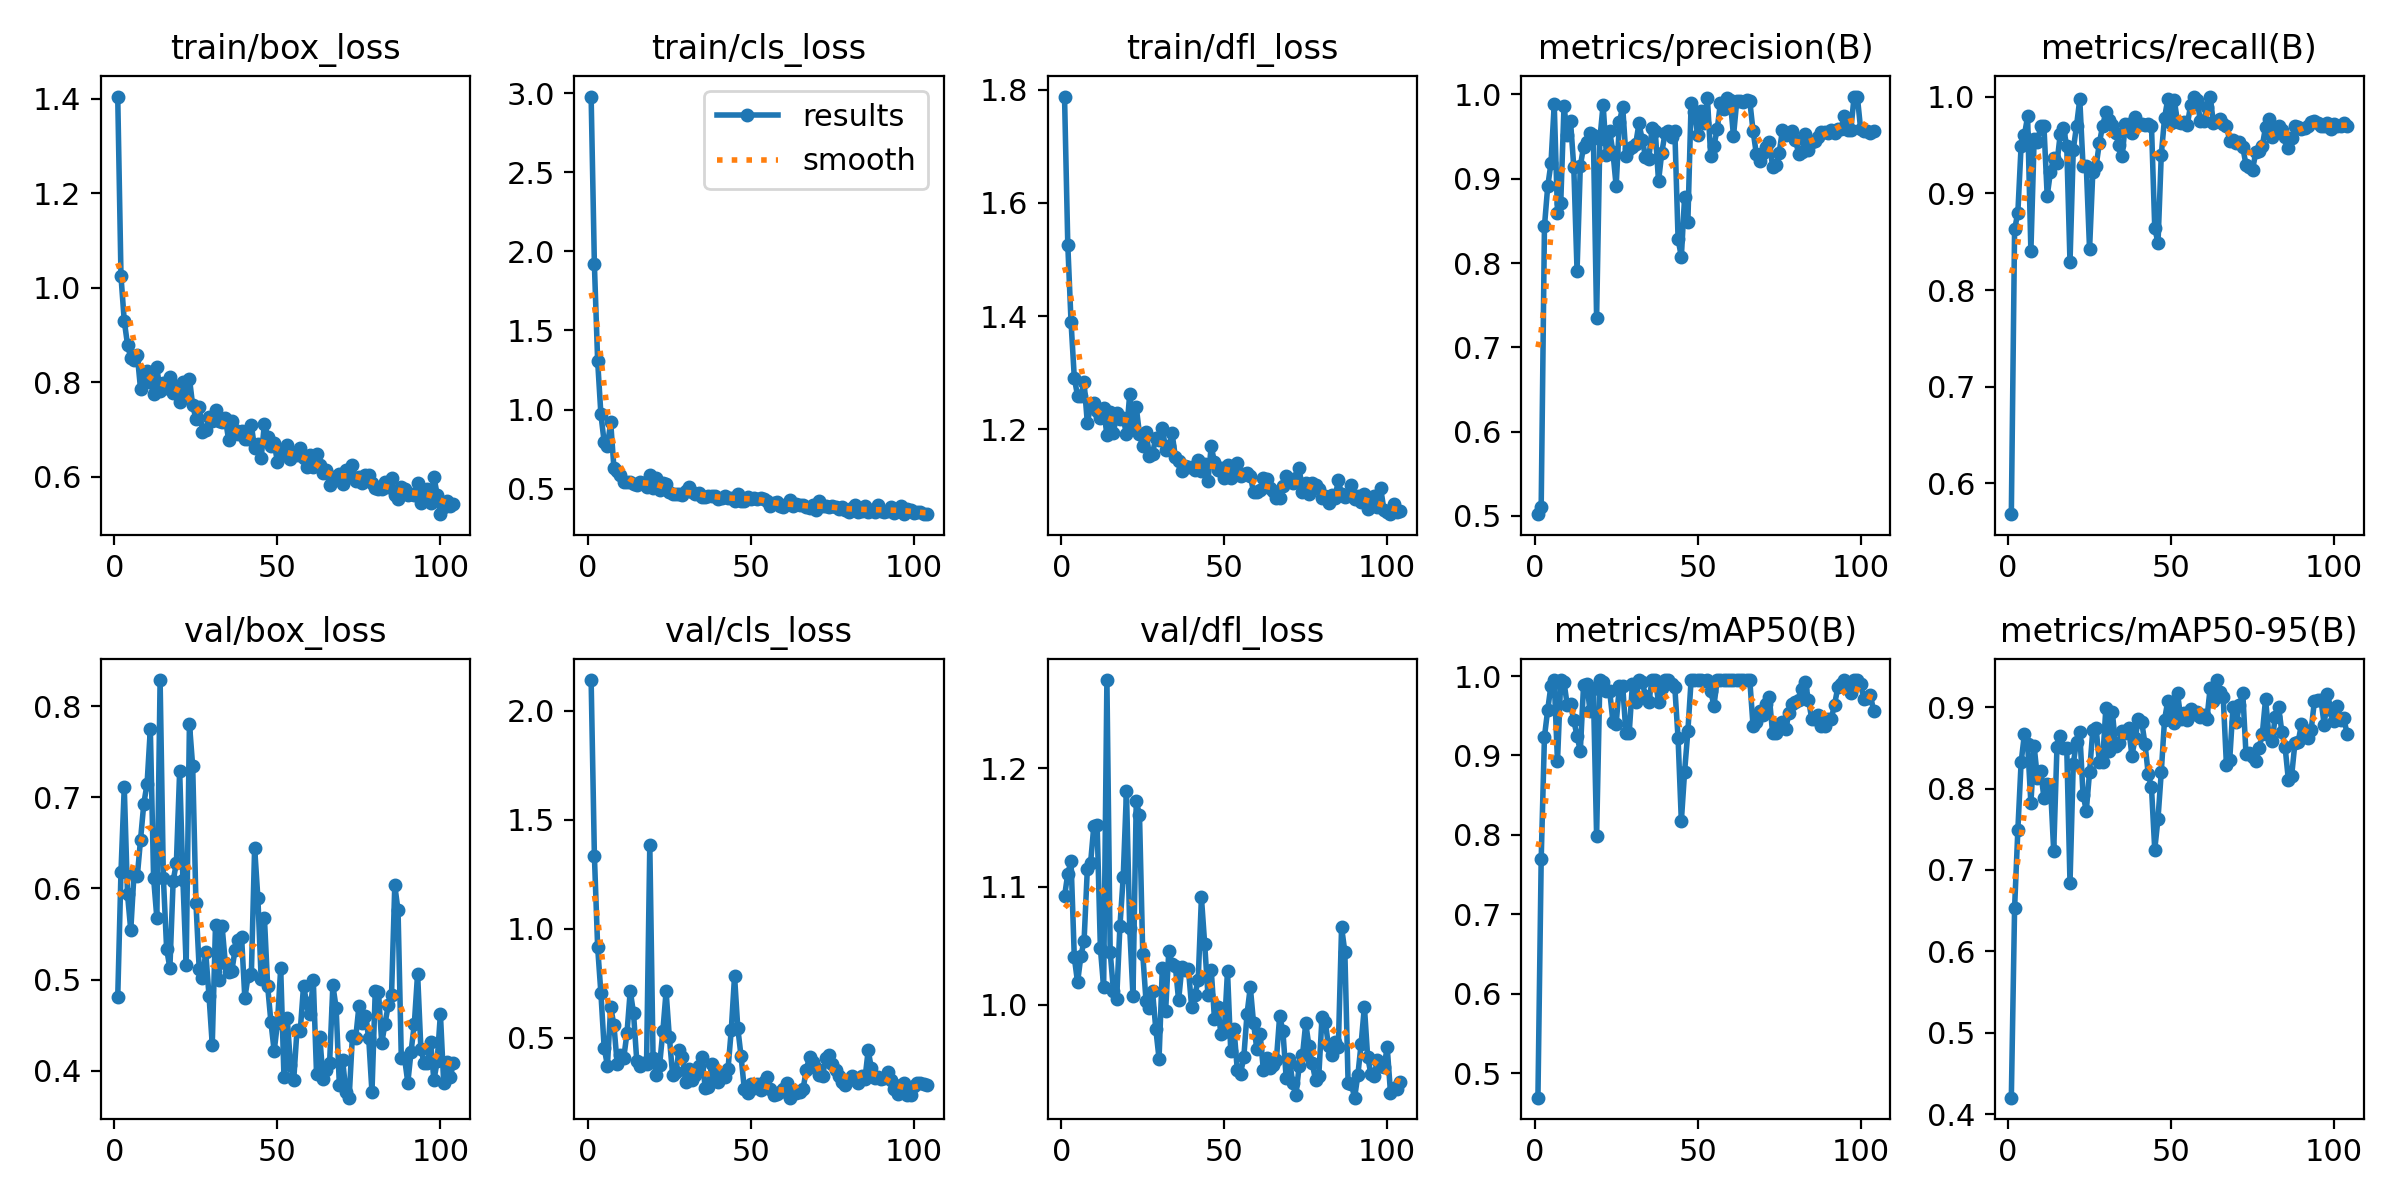


🔲 Matriz de confusión normalizada


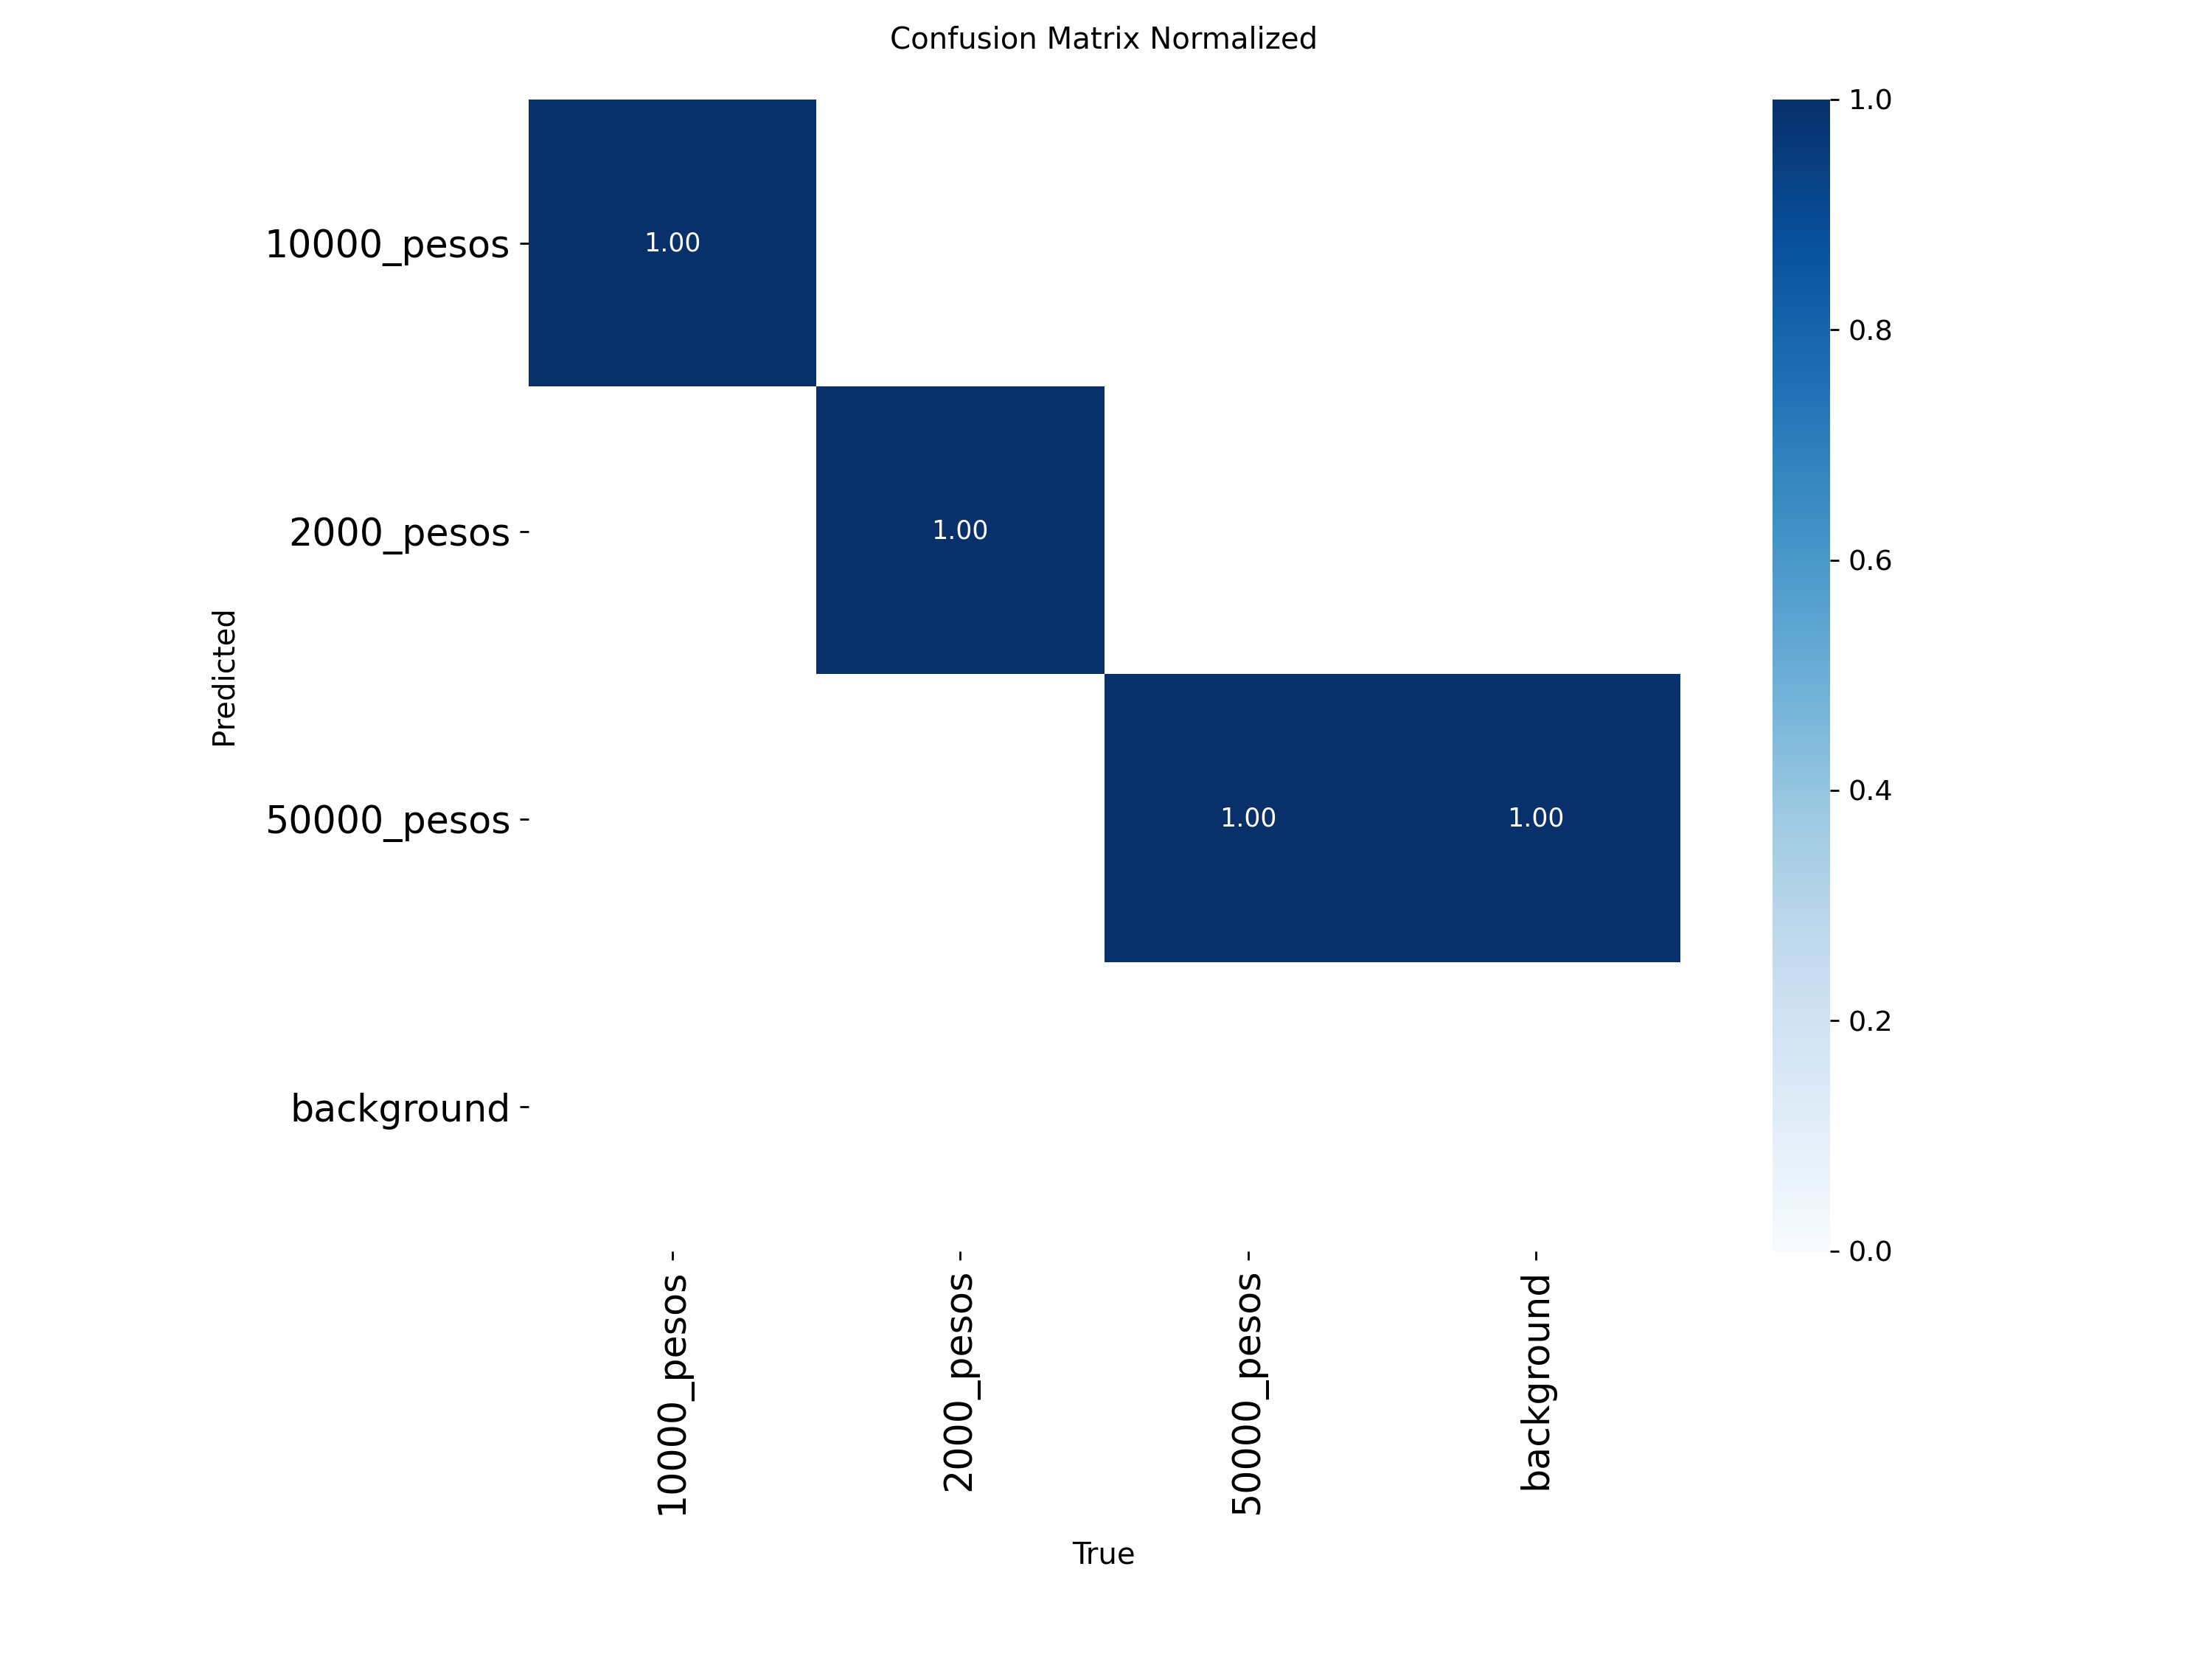

   ⚠️  No encontrado: PR_curve.png
   ⚠️  No encontrado: val_batch0_pred.png


In [9]:
# ============================================================
# VISUALIZACIÓN DE GRÁFICAS DE ENTRENAMIENTO
#
# YOLO genera automáticamente estas gráficas:
#
#   results.png          → curvas de pérdida y mAP por época
#                          Sirve para ver si el modelo convergió
#                          o si necesita más épocas.
#
#   confusion_matrix.png → matriz de confusión normalizada
#                          La diagonal debe ser alta (>0.8).
#                          Valores fuera de la diagonal indican
#                          qué clases el modelo confunde entre sí.
#
#   PR_curve.png         → curva Precision-Recall
#                          El área bajo la curva = mAP.
#
#   val_batch0_pred.png  → ejemplos visuales de detecciones
#                          en el conjunto de validación.
# ============================================================
from IPython.display import Image as IPImage, display
from pathlib import Path

ruta_exp = Path('runs/detect') / NOMBRE_EXPERIMENTO

graficas = [
    ('results.png',               '📈 Curvas de pérdida y mAP por época'),
    ('confusion_matrix_normalized.png',
                                  '🔲 Matriz de confusión normalizada'),
    ('PR_curve.png',              '📉 Curva Precision-Recall'),
    ('val_batch0_pred.png',       '🖼️  Ejemplos de detecciones en validación'),
]

for archivo, titulo in graficas:
    ruta = ruta_exp / archivo
    if ruta.exists():
        print(f"\n{titulo}")
        display(IPImage(str(ruta), width=800))
    else:
        # Algunos archivos tienen nombres alternativos según la versión
        alt = ruta_exp / archivo.replace('_normalized', '')
        if alt.exists():
            print(f"\n{titulo}")
            display(IPImage(str(alt), width=800))
        else:
            print(f"   ⚠️  No encontrado: {archivo}")


 El modelo no confunde ninguna denominación entre sí. En la matriz de confusion se puede ver que el punto a mejorar es que el fondo se puede confundir con los billetes de 50 mil, en la práctica esto se puede controla con el umbral de confianza.

---
## Bloque 5 — Validación con Cámara Real

**¿Por qué esta prueba es la más importante?**

Las métricas de validación (mAP50) se calculan sobre imágenes que vienen del mismo origen que las de entrenamiento (misma cámara, mismas condiciones). Aunque el conjunto de validación no fue visto durante el entrenamiento, comparte características del entorno de captura.

Una cámara real en tiempo de uso produce imágenes con condiciones completamente distintas: fondos complejos, iluminación variable, ángulos oblicuos, manos sujetando el billete, reflejos. Esta es la prueba definitiva.

**¿Cómo funciona en Colab?**  
Colab no tiene acceso directo a la cámara del PC. Usamos JavaScript del navegador para capturar una foto y enviarla al entorno Python para procesarla con el modelo.

**Instrucciones:**
1. Ejecutar la celda — el navegador pedirá permiso para usar la cámara
2. Sostener uno o varios billetes frente a la cámara
3. La celda captura la foto automáticamente después de 3 segundos
4. El modelo procesa la imagen y muestra las detecciones con el total

✅ Modelo cargado: best.pt
   Clases: ['10000_pesos', '2000_pesos', '50000_pesos']
   Confianza mínima: 0.45

📸 Foto 1/3
   Pon los billetes frente a la cámara...
   La foto se tomará en 3 segundos automáticamente.


<IPython.core.display.Javascript object>

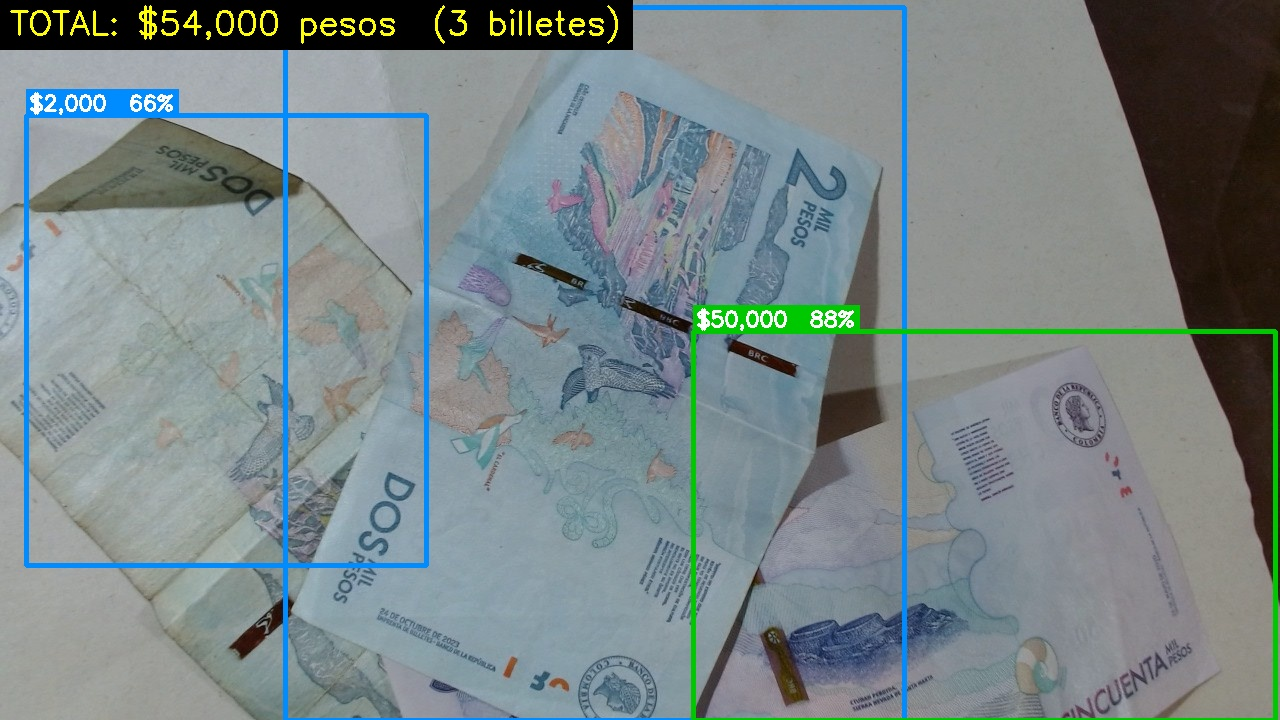


💰 Resultado foto 1:
   Billetes detectados : 3
   Total               : $54,000 pesos

📸 Foto 2/3
   Pon los billetes frente a la cámara...
   La foto se tomará en 3 segundos automáticamente.


<IPython.core.display.Javascript object>

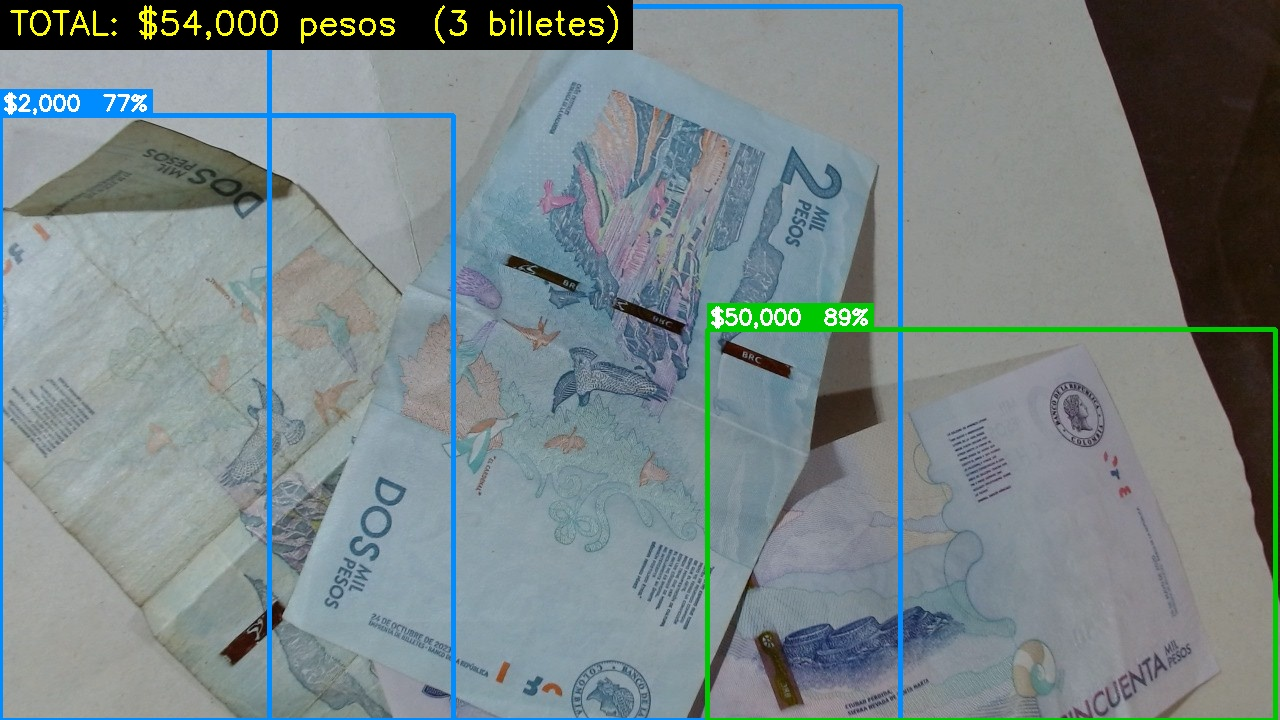


💰 Resultado foto 2:
   Billetes detectados : 3
   Total               : $54,000 pesos

📸 Foto 3/3
   Pon los billetes frente a la cámara...
   La foto se tomará en 3 segundos automáticamente.


<IPython.core.display.Javascript object>

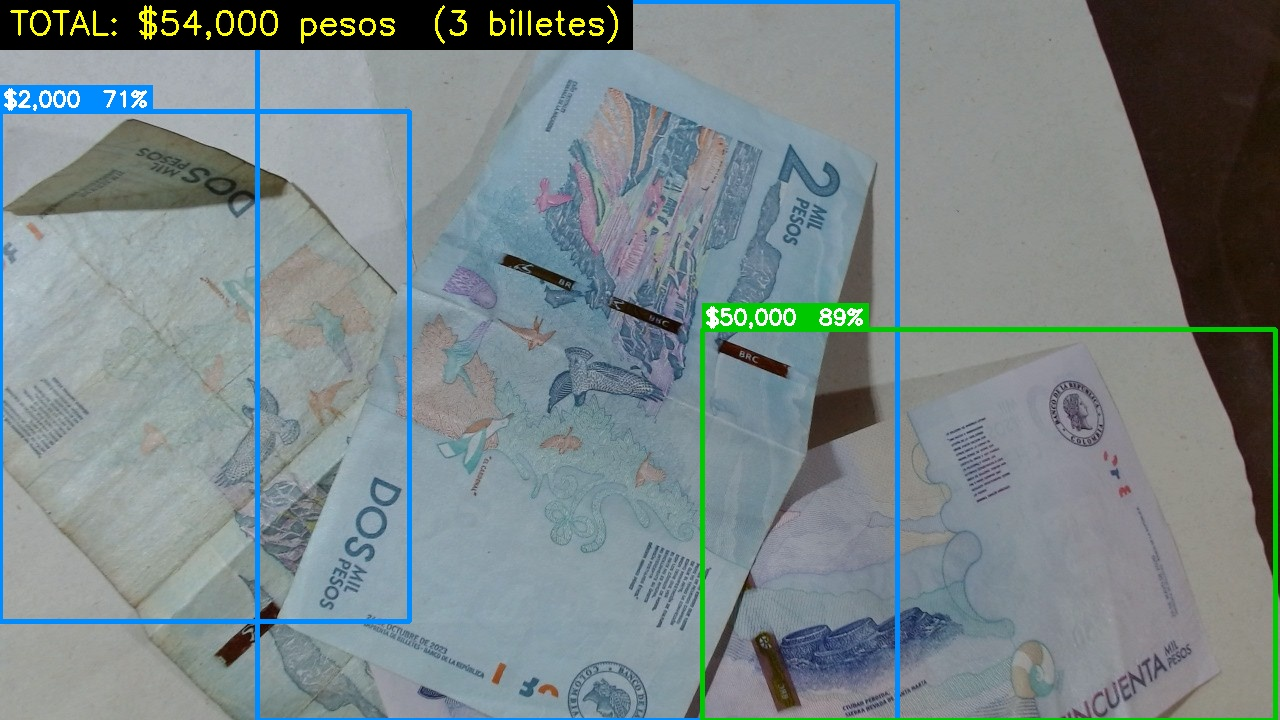


💰 Resultado foto 3:
   Billetes detectados : 3
   Total               : $54,000 pesos

📋 RESUMEN DE VALIDACIÓN CON CÁMARA
   Foto 1: $      54,000 pesos
   Foto 2: $      54,000 pesos
   Foto 3: $      54,000 pesos

✅ Fotos de validación guardadas en Drive


In [13]:
# ============================================================
# CAPTURA DE FOTO CON LA CÁMARA DEL PC DESDE COLAB
#
# Flujo:
#   1. JavaScript activa la cámara del navegador
#   2. Espera 3 segundos para que la imagen se estabilice
#   3. Captura un frame y lo envía a Python como base64
#   4. Python lo convierte a imagen OpenCV
#   5. YOLOv8 detecta los billetes
#   6. Se muestra la imagen con las detecciones y el total
# ============================================================
import cv2
import numpy as np
import tempfile
import os
from base64 import b64decode
from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from ultralytics import YOLO

# Número de fotos a capturar (puedes aumentarlo para probar más casos)
N_FOTOS = 3

# Umbral de confianza: solo mostramos detecciones con
# confianza mayor a este valor (0 a 1).
# Si el modelo detecta poco, bájalo a 0.3.
# Si detecta demasiado con errores, súbelo a 0.6.
CONFIANZA = 0.45

# Función para extraer el valor monetario del nombre de clase
# Ejemplo: '10000_pesos' → 10000
def valor_de_clase(nombre):
    try:
        return int(nombre.split('_pesos')[0])
    except:
        return 0

# Función principal: captura foto y procesa
def capturar_y_detectar(numero_foto, modelo, nombres_clases, confianza):
    print(f"\n{'='*50}")
    print(f"📸 Foto {numero_foto}/{N_FOTOS}")
    print(f"   Pon los billetes frente a la cámara...")
    print(f"   La foto se tomará en 3 segundos automáticamente.")
    print(f"{'='*50}")

    # JavaScript que activa la cámara y captura un frame
    js = Javascript('''
        async function tomarFoto() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({
                video: { width: 1280, height: 720 }
            });
            video.srcObject = stream;
            await video.play();
            // Esperamos 3 segundos para que la imagen se estabilice
            await new Promise(r => setTimeout(r, 3000));
            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(t => t.stop());
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        tomarFoto();
    ''')
    display(js)
    datos_b64 = eval_js('tomarFoto()')

    # Convertimos base64 → imagen OpenCV (formato BGR)
    datos_img = b64decode(datos_b64.split(',')[1])
    arr   = np.frombuffer(datos_img, np.uint8)
    imagen = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    # ── Detección con YOLOv8 ──
    # iou=0.45: elimina detecciones duplicadas del mismo objeto
    # (en el primer entrenamiento aparecían 3 cajas para 1 billete)
    resultados = modelo.predict(
        imagen,
        conf    = confianza,
        iou     = 0.45,
        verbose = False,
    )

    total_pesos   = 0
    n_detecciones = 0

    for res in resultados:
        for box in res.boxes:
            clase_id = int(box.cls[0])
            nombre   = nombres_clases[clase_id]
            conf_val = float(box.conf[0])
            valor    = valor_de_clase(nombre)
            total_pesos   += valor
            n_detecciones += 1

            # Dibujamos bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # Verde para billetes grandes, azul para los más pequeños
            color = (0, 200, 0) if valor >= 10000 else (255, 140, 0)
            cv2.rectangle(imagen, (x1, y1), (x2, y2), color, 3)
            etiqueta = f"${valor:,}  {conf_val:.0%}"
            # Fondo para el texto
            (tw, th), _ = cv2.getTextSize(
                etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(imagen, (x1, y1-th-10), (x1+tw+6, y1), color, -1)
            cv2.putText(imagen, etiqueta, (x1+3, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    # ── Panel de total ──
    panel_txt = f"TOTAL: ${total_pesos:,} pesos  ({n_detecciones} billetes)"
    (pw, ph), _ = cv2.getTextSize(
        panel_txt, cv2.FONT_HERSHEY_SIMPLEX, 1.1, 2)
    cv2.rectangle(imagen, (0, 0), (pw+20, ph+25), (0,0,0), -1)
    cv2.putText(imagen, panel_txt, (10, ph+10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,255,255), 2)

    # Guardamos y mostramos
    nombre_archivo = f'/content/validacion_camara_{numero_foto}.jpg'
    cv2.imwrite(nombre_archivo, imagen)
    display(IPImage(nombre_archivo, width=800))

    print(f"\n💰 Resultado foto {numero_foto}:")
    print(f"   Billetes detectados : {n_detecciones}")
    print(f"   Total               : ${total_pesos:,} pesos")
    if n_detecciones == 0:
        print("   ⚠️  Sin detecciones — intenta con mejor iluminación")
        print(f"      o baja CONFIANZA (actual: {confianza})")

    return total_pesos, nombre_archivo


# ── Cargamos el modelo ──
modelo_camara  = YOLO(str(RUTA_MEJOR_MODELO))
nombres_clases = config_yaml['names']

print(f"✅ Modelo cargado: {RUTA_MEJOR_MODELO.name}")
print(f"   Clases: {nombres_clases}")
print(f"   Confianza mínima: {CONFIANZA}")

# ── Capturamos N_FOTOS fotos ──
fotos_capturadas = []
for i in range(1, N_FOTOS + 1):
    total, archivo = capturar_y_detectar(
        i, modelo_camara, nombres_clases, CONFIANZA)
    fotos_capturadas.append({'foto': i, 'total': total, 'archivo': archivo})

# ── Resumen final ──
print("\n" + "="*50)
print("📋 RESUMEN DE VALIDACIÓN CON CÁMARA")
print("="*50)
for f in fotos_capturadas:
    print(f"   Foto {f['foto']}: ${f['total']:>12,} pesos")

# Copiamos las fotos de validación a Drive para el informe
for f in fotos_capturadas:
    dst = f"/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/{os.path.basename(f['archivo'])}"
    try:
        import shutil
        shutil.copy(f['archivo'], dst)
    except:
        pass
print("\n✅ Fotos de validación guardadas en Drive")


---
## Bloque 6 — Guardar y Exportar el Modelo

**¿Qué hace este bloque?**

1. **Guarda `best.pt` en Google Drive** para no perderlo cuando la sesión de Colab expire.

2. **Exporta a formato ONNX** — formato universal compatible con cualquier dispositivo. Sirve para correr el modelo en MacBook, PC con Windows/Linux, o cualquier entorno sin necesidad de instalar PyTorch completo.

3. **Exporta a TensorRT** para la Jetson Nano Orin — este es el formato optimizado para la GPU NVIDIA de la Jetson. TensorRT analiza la arquitectura del modelo y genera una versión compilada específicamente para esa GPU, logrando **2-4x más velocidad** que el modelo original.

> ⚠️ **Importante sobre TensorRT:** la exportación a `.engine` debe ejecutarse **directamente en la Jetson Nano**, porque el archivo generado es específico para esa GPU. No se puede exportar en Colab y usar en Jetson. El flujo correcto es: copiar `best.pt` a la Jetson → ejecutar este bloque allí.

**Flujo para usar en Jetson Nano Orin:**
```
1. Copiar best.pt a la Jetson (scp o USB)
2. Instalar: pip install ultralytics
3. Ejecutar la celda de exportación TensorRT en la Jetson
4. Usar el archivo .engine para inferencia en tiempo real
```

In [14]:
# ============================================================
# PASO 1: Guardar el modelo en Google Drive
#
# La sesión de Colab tiene un tiempo límite. Cuando expira,
# todo lo que está en /content/ se borra permanentemente.
# Guardamos el modelo en Drive para no perder el trabajo.
# ============================================================
import shutil
from pathlib import Path

# Ruta de destino en Drive
ruta_destino_drive = (
    f'/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/'
    f'mejor_modelo_billetes_1.pt'
)

shutil.copy(str(RUTA_MEJOR_MODELO), ruta_destino_drive)
tamanio = Path(ruta_destino_drive).stat().st_size / 1e6
print(f"✅ Modelo guardado en Drive:")
print(f"   {ruta_destino_drive}")
print(f"   Tamaño: {tamanio:.1f} MB")

# También guardamos el data.yaml para referencia futura
ruta_yaml_drive = (
    '/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/data.yaml'
)
shutil.copy(RUTA_YAML, ruta_yaml_drive)
print(f"\n✅ data.yaml guardado en Drive")
print(f"   (necesario para saber qué clases tiene el modelo)")


✅ Modelo guardado en Drive:
   /content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/mejor_modelo_billetes_1.pt
   Tamaño: 52.0 MB

✅ data.yaml guardado en Drive
   (necesario para saber qué clases tiene el modelo)


In [15]:
# ============================================================
# PASO 2: Exportar a ONNX
#
# ONNX (Open Neural Network Exchange) es un formato abierto
# que permite correr el modelo en cualquier dispositivo y
# framework sin necesidad de tener PyTorch instalado.
#
# Úsalo en:
#   - MacBook (con onnxruntime)
#   - PC Windows/Linux sin GPU
#   - Como paso intermedio para otras plataformas
#
# Para inferencia en Python con ONNX:
#   modelo = YOLO('best.onnx')
#   resultados = modelo.predict(imagen)
# ============================================================
from ultralytics import YOLO

modelo_export = YOLO(str(RUTA_MEJOR_MODELO))

print("📦 Exportando a ONNX...")
ruta_onnx = modelo_export.export(
    format   = 'onnx',
    imgsz    = TAMANO_IMAGEN,
    dynamic  = False,   # tamaño de entrada fijo (más rápido en inferencia)
    simplify = True,    # simplifica el grafo de operaciones
    opset    = 12,      # versión de ONNX (12 = buena compatibilidad)
)
tamanio = Path(str(ruta_onnx)).stat().st_size / 1e6
print(f"\n✅ Modelo ONNX generado:")
print(f"   {ruta_onnx}")
print(f"   Tamaño: {tamanio:.1f} MB")

# Copiamos a Drive
ruta_onnx_drive = (
    f'/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/'
    f'mejor_modelo_{NOMBRE_EXPERIMENTO}.onnx'
)
shutil.copy(str(ruta_onnx), ruta_onnx_drive)
print(f"\n✅ Modelo ONNX guardado en Drive: {ruta_onnx_drive}")


📦 Exportando a ONNX...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (AMD EPYC 9B45)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/runs/detect/billetes_3clases_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 171ms
Prepared 4 packages in 4.48s
Installed 4 packages in 149ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 5.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 6.4s, saved as '/content/runs/detect/billetes_3clases_final/

In [16]:
# ============================================================
# PASO 3: Exportar a TensorRT para Jetson Nano Orin
#
# TensorRT es el motor de inferencia de NVIDIA optimizado para
# sus GPUs. Compila el modelo y genera un archivo .engine
# específico para la GPU del dispositivo donde se ejecuta.
#
# RESULTADO: 2-4x más velocidad que el modelo .pt original,
# lo cual es fundamental para detección en tiempo real en la
# Jetson Nano Orin.
#
# ⚠️  INSTRUCCIONES DE USO:
#
#   Este bloque tiene DOS modos:
#
#   MODO A — En Colab (ahora):
#     No se puede exportar TensorRT para Jetson desde Colab
#     porque el .engine es específico para cada GPU.
#     Se generan las instrucciones para hacerlo en la Jetson.
#
#   MODO B — En Jetson Nano Orin:
#     1. Copiar best.pt a la Jetson:
#        scp best.pt usuario@IP_JETSON:/home/usuario/
#     2. Instalar ultralytics en la Jetson:
#        pip install ultralytics
#     3. Ejecutar este bloque directamente en la Jetson
#        (cambiando EJECUTAR_EN_JETSON = True)
# ============================================================

# Cambia a True cuando ejecutes DESDE LA JETSON NANO
EJECUTAR_EN_JETSON = False

if EJECUTAR_EN_JETSON:
    from ultralytics import YOLO
    import os

    # Ajusta esta ruta a donde copiaste best.pt en la Jetson
    RUTA_MODELO_EN_JETSON = '/home/usuario/mejor_modelo_billetes.pt'

    modelo_trt = YOLO(RUTA_MODELO_EN_JETSON)

    print("🔥 Exportando a TensorRT FP16 para Jetson Nano Orin...")
    print("   Esto puede tardar 5-15 minutos la primera vez...")

    ruta_engine = modelo_trt.export(
        format    = 'engine',   # TensorRT
        imgsz     = TAMANO_IMAGEN,
        half      = True,       # FP16: mitad de precisión, doble velocidad
                                # la Jetson Orin lo soporta nativamente
        device    = 0,          # GPU 0 de la Jetson
        workspace = 4,          # GB de RAM para optimización (Orin tiene 8GB)
        verbose   = True,
    )

    print(f"\n✅ Modelo TensorRT generado: {ruta_engine}")
    print("\n📋 Para usarlo en inferencia:")
    print("   from ultralytics import YOLO")
    print("   modelo = YOLO('mejor_modelo_billetes.engine')")
    print("   resultados = modelo.predict(frame, conf=0.45, iou=0.45)")

else:
    # Modo Colab: mostramos instrucciones completas
    ruta_pt_drive = (
        f'/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/'
        f'mejor_modelo_{NOMBRE_EXPERIMENTO}.pt'
    )
    print("ℹ️  Exportación TensorRT — para ejecutar en Jetson Nano Orin")
    print("="*60)
    print("\n📋 PASOS PARA INSTALAR EN LA JETSON:")
    print()
    print("  1. Copia el modelo desde Drive a la Jetson:")
    print(f"     El archivo está en tu Drive:")
    print(f"     {ruta_pt_drive}")
    print()
    print("  2. Pásalo a la Jetson por USB o red:")
    print("     scp mejor_modelo.pt usuario@IP_JETSON:/home/usuario/")
    print()
    print("  3. En la Jetson, instala las dependencias:")
    print("     pip install ultralytics")
    print()
    print("  4. En la Jetson, abre este notebook y:")
    print("     a) Cambia EJECUTAR_EN_JETSON = True")
    print("     b) Ajusta RUTA_MODELO_EN_JETSON")
    print("     c) Ejecuta este bloque")
    print()
    print("  5. Para inferencia en tiempo real con cámara USB:")
    print("     from ultralytics import YOLO")
    print("     import cv2")
    print()
    print("     modelo = YOLO('mejor_modelo_billetes.engine')")
    print("     camara = cv2.VideoCapture(0)  # 0=cámara USB")
    print()
    print("     while True:")
    print("         ok, frame = camara.read()")
    print("         res = modelo.predict(frame, conf=0.45, iou=0.45)")
    print("         total = sum(int(modelo.names[int(b.cls)].split('_')[0])")
    print("                     for r in res for b in r.boxes)")
    print("         cv2.putText(frame, f'TOTAL: ${total:,}',")
    print("                     (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1.2,")
    print("                     (0,255,255), 2)")
    print("         cv2.imshow('Detector', frame)")
    print("         if cv2.waitKey(1) & 0xFF == ord('q'): break")
    print()
    print("     camara.release()")
    print("     cv2.destroyAllWindows()")
    print()
    print("💡 Tip: con el modelo .engine el rendimiento típico")
    print("   en Jetson Orin 8GB es de 30-60 FPS en tiempo real.")


ℹ️  Exportación TensorRT — para ejecutar en Jetson Nano Orin

📋 PASOS PARA INSTALAR EN LA JETSON:

  1. Copia el modelo desde Drive a la Jetson:
     El archivo está en tu Drive:
     /content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/mejor_modelo_billetes_3clases_final.pt

  2. Pásalo a la Jetson por USB o red:
     scp mejor_modelo.pt usuario@IP_JETSON:/home/usuario/

  3. En la Jetson, instala las dependencias:
     pip install ultralytics

  4. En la Jetson, abre este notebook y:
     a) Cambia EJECUTAR_EN_JETSON = True
     b) Ajusta RUTA_MODELO_EN_JETSON
     c) Ejecuta este bloque

  5. Para inferencia en tiempo real con cámara USB:
     from ultralytics import YOLO
     import cv2

     modelo = YOLO('mejor_modelo_billetes.engine')
     camara = cv2.VideoCapture(0)  # 0=cámara USB

     while True:
         ok, frame = camara.read()
         res = modelo.predict(frame, conf=0.45, iou=0.45)
         total = sum(int(modelo.names[int(b.cls)].split('_')[0])
                     f

---
## Notebook completado

### Archivos generados en Google Drive (`Proyecto_innovacion_2/Tarea_2/`):

| Archivo | Descripción |
|---------|-------------|
| `mejor_modelo_billetes_3clases_final.pt` | Modelo PyTorch — para reentrenar o evaluar |
| `mejor_modelo_billetes_3clases_final.onnx` | Modelo ONNX — para MacBook y PC |
| `data.yaml` | Configuración del dataset con las 3 clases |
| `validacion_camara_1/2/3.jpg` | Fotos de la validación con cámara real |

### Conclusion:

El modelo cumple con el cometido de identificar los billes de forma correcta para las tres clases sobre las que fue entrenado, las pruebas robustas utilizando la camara el resultado fue mas que sobresaliente. Tambien se encontra que es necesario mejorar el modelo para que no confunda el fondo de las imagenes con billetes, en las validaciones con la camara y en la matriz de confusion se evidencia ese punto critico conlos fondos, se podria volver a entrenar integrando nuevas imagenes que no esten etiquetadas para que el modelo pueda aprender que no es un billete

### Resumen técnico:

- **Arquitectura:** YOLOv8m con Transfer Learning desde COCO
- **Clases:** `2000_pesos`, `10000_pesos`, `50000_pesos`
- **Dataset:** imágenes etiquetadas en Roboflow con augmentación previa (brillo, rotación, flip)
- **Augmentación al vuelo:** perspectiva, cizallamiento, mosaic, copy_paste, mixup, erasing
- **Optimizador:** SGD (mejor generalización que Adam en datasets pequeños)
- **Problema resuelto:** overfitting en validación pero fallo en cámara real, corregido con augmentación de perspectiva y copy_paste
- **Despliegue objetivo:** Jetson Nano Orin 8GB con TensorRT FP16

In [ ]:
import shutil

# Solo copiamos el que SÍ existe
shutil.copy(
    '/content/runs/detect/billetes_monedas_v2/weights/best.pt',
    '/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/modelo_v2_3clases.pt'
)
print(" Modelo v2 (3 clases) guardado en Drive")

In [ ]:
shutil.copy(
    '/content/runs/detect/billetes_monedas_v2/weights/best.onnx',
    '/content/drive/MyDrive/Proyecto_innovacion_2/Tarea_2/modelo_v2_3clases.onnx'
)